C:\Users\DELL\AppData\Local\Temp\ipykernel_7656\2570578306.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

Successfully loaded best_generator.pth


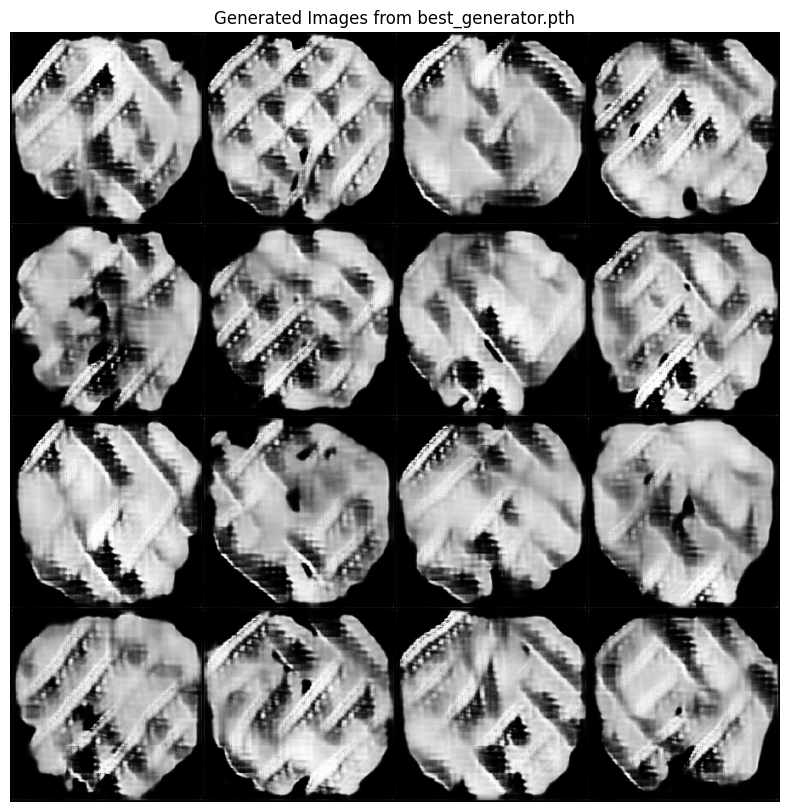

In [2]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from src.model import Generator  # Ensure your src folder is in the same directory

# --- Configuration ---
Z_DIM = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = "best_generator.pth" # or "generator_checkpoint.pth"
NUM_IMAGES = 16

def show_generated_images():
    # 1. Initialize Model
    gen = Generator(Z_DIM).to(DEVICE)
    
    # 2. Load Weights
    try:
        # Check if it's a full checkpoint (dict) or just state_dict
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
        if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
            gen.load_state_dict(checkpoint["state_dict"])
        else:
            gen.load_state_dict(checkpoint)
        print(f"Successfully loaded {CHECKPOINT_PATH}")
    except FileNotFoundError:
        print("Checkpoint not found. Please check the path.")
        return

    gen.eval()

    # 3. Generate Images
    with torch.no_grad():
        noise = torch.randn(NUM_IMAGES, Z_DIM).to(DEVICE)
        fake_images = gen(noise)
        
        # De-normalize from [-1, 1] to [0, 1] for visualization
        fake_images = (fake_images * 0.5) + 0.5
        
        # Create Grid
        grid = make_grid(fake_images, nrow=4).cpu().permute(1, 2, 0)

    # 4. Plot
    plt.figure(figsize=(10, 10))
    plt.imshow(grid, cmap='gray')
    plt.axis("off")
    plt.title(f"Generated Images from {CHECKPOINT_PATH}")
    plt.show()

# Run the function
show_generated_images()